# Part 3: AI Market "Weight & Impact" Analysis
---
## Analyzing the Size and Impact of AI Stocks on the S&P 500

This notebook addresses four critical questions:
1. **Weight Analysis** — How large are these 8 AI stocks relative to the entire S&P 500?
2. **GDP Reality Check** — Are these companies overvalued when compared to the real economy?
3. **Market Breadth Analysis** — Is the market rally broad-based or driven only by AI?
4. **Crash Simulation** — If the AI bubble bursts, how badly would the market suffer?

**AI Stocks (8 tickers):** NVDA, AMD, AMZN, GOOGL, META, MSFT, ORCL, PLTR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Style Configuration
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': '#1a1a1a',
    'axes.labelcolor': '#1a1a1a',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#cccccc',
    'grid.color': '#e0e0e0',
    'grid.alpha': 0.6,
    'figure.dpi': 300,
    'legend.facecolor': 'white',
    'legend.edgecolor': '#cccccc',
    'legend.fontsize': 11,
})
sns.set_style("darkgrid", {
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'grid.color': '#e0e0e0',
})

# Color Palette
COLORS = {
    'NVDA': '#76B900',
    'AMD': '#ED1C24',
    'AMZN': '#FF9900',
    'GOOGL': '#4285F4',
    'META': '#0668E1',
    'MSFT': '#00BCF2',
    'ORCL': '#F80000',
    'PLTR': '#101010',
}
COLORS_LIST = ['#76B900', '#ED1C24', '#FF9900', '#4285F4', '#0668E1', '#00BCF2', '#F80000', '#333333']

AI_TICKERS = ['NVDA', 'AMD', 'AMZN', 'GOOGL', 'META', 'MSFT', 'ORCL', 'PLTR']

print("Setup complete - Ready for analysis")

Setup complete - Ready for analysis


---
## Data Loading

In [ ]:
# Load AI Stock Market Cap Data
AI_TICKERS = ['NVDA', 'AMD', 'AMZN', 'GOOGL', 'META', 'MSFT', 'ORCL', 'PLTR']

# Create a lookup table (like a reference sheet in Excel)
lookup = pd.DataFrame({
    'Ticker': AI_TICKERS,
    'stock_name': ['NVIDIA', 'AMD', 'Amazon', 'Alphabet (Google)', 
                   'Meta Platforms', 'Microsoft', 'Oracle', 'Palantir']
})

# Load all 8 CSV files and combine into one DataFrame
frames = []
for ticker in AI_TICKERS:
    df = pd.read_csv(f'{ticker}_market_cap_2023_2025.csv', parse_dates=['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df['Ticker'] = ticker
    frames.append(df)

all_stocks = pd.concat(frames, ignore_index=True)

# VLOOKUP: merge with lookup to add stock_name
all_stocks = all_stocks.merge(lookup, on='Ticker', how='left')

# Reorder columns
all_stocks = all_stocks[['Ticker', 'stock_name', 'Date', 'Close', 'Shares_Outstanding', 'Market_Cap']]

# Display summary
for ticker in AI_TICKERS:
    sub = all_stocks[all_stocks['Ticker'] == ticker]
    latest = sub.iloc[-1]
    print(f"{ticker:6s} | Latest: {latest['Date'].strftime('%Y-%m-%d')} | "
          f"Market Cap: ${latest['Market_Cap']/1e12:.3f}T | "
          f"Close: ${latest['Close']:.2f}")

print("\n" + "="*70)
print(f"Combined table: {len(all_stocks):,} rows x {len(all_stocks.columns)} columns")
print(f"[OK] Loaded and merged all 8 AI stocks")
display(all_stocks.head(10))

NVDA   | Latest: 2025-12-30 | Market Cap: $4.566T | Close: $187.54
AMD    | Latest: 2025-12-30 | Market Cap: $0.351T | Close: $215.34
AMZN   | Latest: 2025-12-30 | Market Cap: $2.486T | Close: $232.53
GOOGL  | Latest: 2025-12-30 | Market Cap: $3.801T | Close: $313.85
META   | Latest: 2025-12-30 | Market Cap: $1.679T | Close: $665.95
MSFT   | Latest: 2025-12-30 | Market Cap: $3.624T | Close: $487.48
ORCL   | Latest: 2025-12-30 | Market Cap: $0.565T | Close: $196.69
PLTR   | Latest: 2025-12-30 | Market Cap: $0.431T | Close: $180.84

Combined table: 6,008 rows x 6 columns
[OK] Loaded and merged all 8 AI stocks


,Ticker,stock_name,Date,Close,Shares_Outstanding,Market_Cap
0,NVDA,NVIDIA,2023-01-03,14.300684,2.470000e+09,3.532269e+10
1,NVDA,NVIDIA,2023-01-04,14.734249,2.470000e+09,3.639360e+10
2,NVDA,NVIDIA,2023-01-05,14.250734,2.470000e+09,3.519932e+10
3,NVDA,NVIDIA,2023-01-06,14.844141,2.470000e+09,3.666503e+10
4,NVDA,NVIDIA,2023-01-09,15.612371,2.470000e+09,3.856256e+10
5,NVDA,NVIDIA,2023-01-10,15.893090,2.470000e+09,3.925593e+10
6,NVDA,NVIDIA,2023-01-11,15.984998,2.470000e+09,3.948295e+10
7,NVDA,NVIDIA,2023-01-12,16.494484,2.470000e+09,4.074138e+10
8,NVDA,NVIDIA,2023-01-13,16.882103,2.470000e+09,4.169880e+10
9,NVDA,NVIDIA,2023-01-17,17.684299,2.470000e+09,4.368022e+10


In [6]:
# Load S&P 500 Index Data
gspc = pd.read_csv('GSPC_2023_2025.csv', header=[0,1], index_col=0)
gspc.columns = gspc.columns.get_level_values(0)
gspc.index.name = 'Date'
gspc.index = pd.to_datetime(gspc.index)
gspc = gspc.sort_index()

# Load S&P 500 Equal Weight Index Data
sp500ew = pd.read_csv('SP500EW_2023_2025.csv', header=[0,1], index_col=0)
sp500ew.columns = sp500ew.columns.get_level_values(0)
sp500ew.index.name = 'Date'
sp500ew.index = pd.to_datetime(sp500ew.index)
sp500ew = sp500ew.sort_index()

print(f"S&P 500 (GSPC)  | Range: {gspc.index.min().strftime('%Y-%m-%d')} to {gspc.index.max().strftime('%Y-%m-%d')} | Latest Close: {gspc['Close'].iloc[-1]:,.2f}")
print(f"S&P 500 EW      | Range: {sp500ew.index.min().strftime('%Y-%m-%d')} to {sp500ew.index.max().strftime('%Y-%m-%d')} | Latest Close: {sp500ew['Close'].iloc[-1]:,.2f}")
print("\nLoaded S&P 500 and Equal Weight index data")

S&P 500 (GSPC)  | Range: 2023-01-03 to 2025-12-30 | Latest Close: 6,896.24
S&P 500 EW      | Range: 2023-01-03 to 2025-12-30 | Latest Close: 7,832.61

Loaded S&P 500 and Equal Weight index data


---
# 1. The "Weight" Analysis - AI Market Share in the S&P 500
---

### Objective
How large are these 8 AI stocks relative to the entire S&P 500 market?

### Methodology
1. Retrieve the latest Market Cap for all 8 stocks
2. Sum total AI Market Cap
3. Calculate proportion: (Total AI Market Cap / S&P 500 Market Cap) x 100

If these 8 stocks account for more than 30% of the market, a sharp decline in AI names
would immediately drag the S&P 500 into deeply negative territory.

In [5]:
# Calculate Market Cap & Weight in S&P 500 
SP500_TOTAL_MARKET_CAP = 50e12

# Get latest Market Cap for each ticker from all_stocks
latest_dates = all_stocks.groupby('Ticker')['Date'].max().reset_index()
latest_data = all_stocks.merge(latest_dates, on=['Ticker', 'Date'])

mcap_df = latest_data[['Ticker', 'stock_name', 'Market_Cap']].copy()
mcap_df = mcap_df.rename(columns={'Market_Cap': 'Market_Cap_USD'})
mcap_df['Market_Cap_T'] = mcap_df['Market_Cap_USD'] / 1e12
mcap_df['Weight_Pct'] = (mcap_df['Market_Cap_USD'] / SP500_TOTAL_MARKET_CAP) * 100
mcap_df = mcap_df.sort_values('Market_Cap_T', ascending=False).reset_index(drop=True)

total_ai_mcap = mcap_df['Market_Cap_USD'].sum()
total_ai_weight = (total_ai_mcap / SP500_TOTAL_MARKET_CAP) * 100

print("=" * 70)
print("MARKET CAP & WEIGHT OF 8 AI STOCKS")
print("=" * 70)
print(f"{'Rank':<7} {'Ticker':<8} {'Name':<20} {'Market Cap (T$)':<18} {'Weight (%)':<10}")
print("-" * 65)
for i, row in mcap_df.iterrows():
    print(f"  {i+1:<5}  {row['Ticker']:<8} {row['stock_name']:<20} ${row['Market_Cap_T']:<16.3f} {row['Weight_Pct']:.2f}%")
print("-" * 65)
print(f"  {'Total':<13} {'':20s} ${total_ai_mcap/1e12:<16.3f} {total_ai_weight:.2f}%")
print(f"\n  S&P 500 Total Market Cap (est.): ${SP500_TOTAL_MARKET_CAP/1e12:.0f} Trillion")
print("=" * 70)

MARKET CAP & WEIGHT OF 8 AI STOCKS
Rank    Ticker   Name                 Market Cap (T$)    Weight (%)
-----------------------------------------------------------------
  1      NVDA     NVIDIA               $4.566            9.13%
  2      GOOGL    Alphabet (Google)    $3.801            7.60%
  3      MSFT     Microsoft            $3.624            7.25%
  4      AMZN     Amazon               $2.486            4.97%
  5      META     Meta Platforms       $1.679            3.36%
  6      ORCL     Oracle               $0.565            1.13%
  7      PLTR     Palantir             $0.431            0.86%
  8      AMD      AMD                  $0.351            0.70%
-----------------------------------------------------------------
  Total                              $17.502           35.00%

  S&P 500 Total Market Cap (est.): $50 Trillion


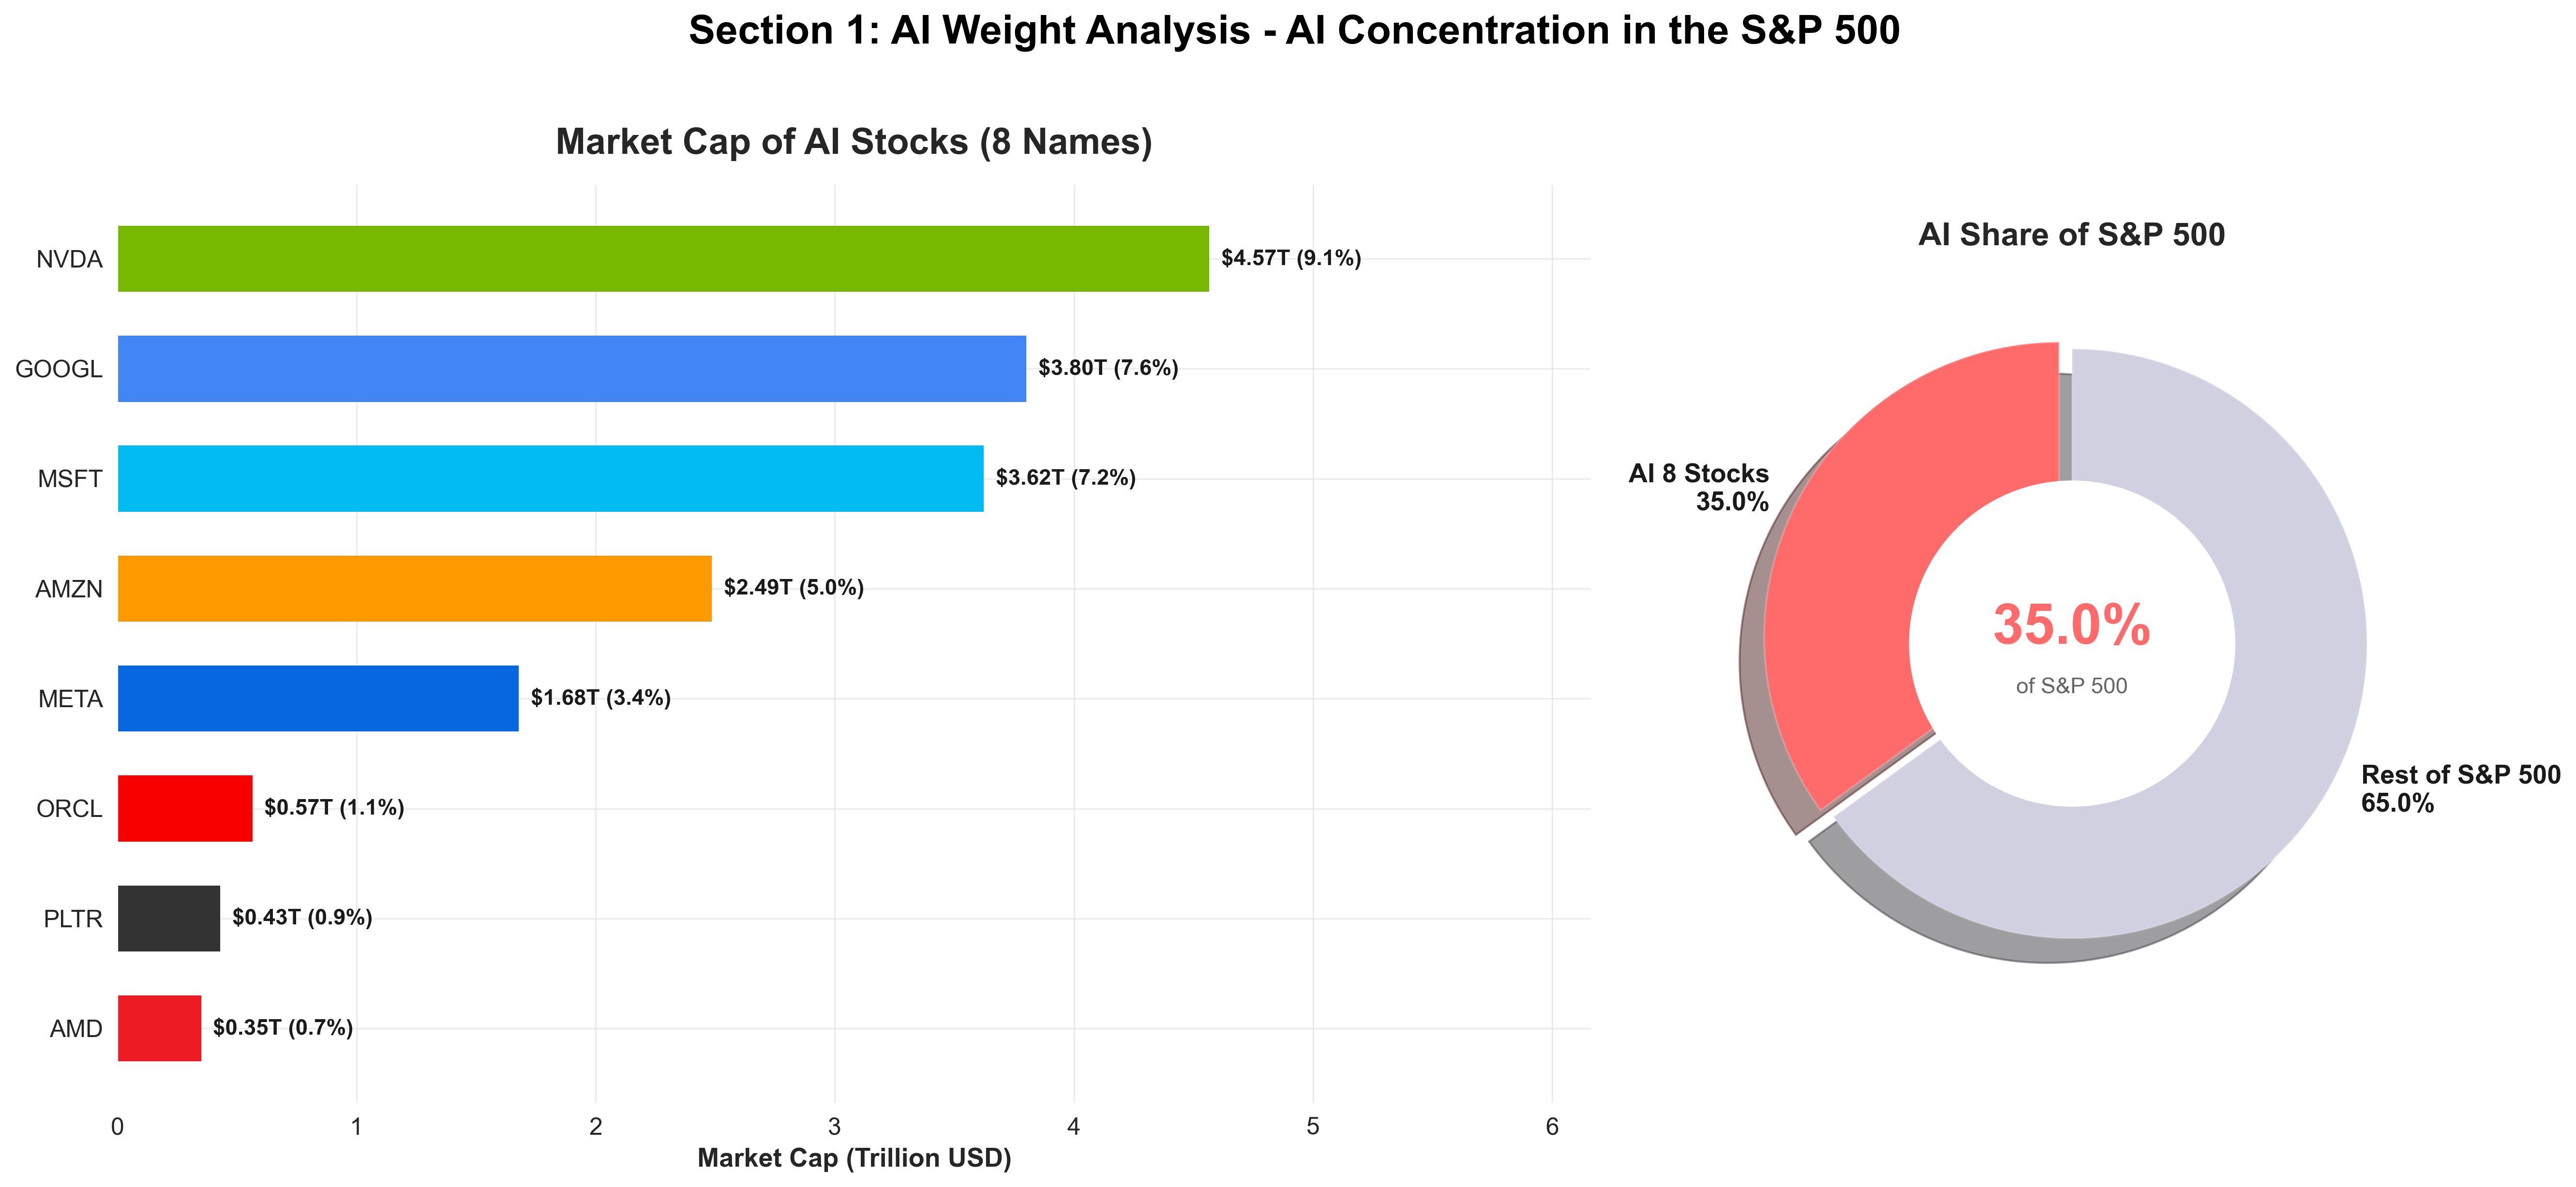

In [8]:
# Visualization: AI Weight in S&P 500
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [2, 1]})

# LEFT: Bar Chart - Individual Weights
ax1 = axes[0]
bars_colors = ['#333333' if t == 'PLTR' else COLORS.get(t, '#888888') for t in mcap_df['Ticker']]

bars = ax1.barh(mcap_df['Ticker'], mcap_df['Market_Cap_T'], color=bars_colors,
                edgecolor='#00000011', linewidth=0.5, height=0.6)
ax1.set_xlabel('Market Cap (Trillion USD)', fontweight='bold')
ax1.set_title('Market Cap of AI Stocks (8 Names)', fontsize=18, fontweight='bold', pad=15)
ax1.invert_yaxis()

# Add value labels
for bar, row in zip(bars, mcap_df.itertuples()):
    width = bar.get_width()
    ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2,
             f'${width:.2f}T ({row.Weight_Pct:.1f}%)',
             va='center', fontsize=11, color='#1a1a1a', fontweight='bold')
ax1.set_xlim(0, mcap_df['Market_Cap_T'].max() * 1.35)

# RIGHT: Donut Chart - AI vs Rest of S&P 500
ax2 = axes[1]
rest_weight = 100 - total_ai_weight
sizes = [total_ai_weight, rest_weight]
labels = [f'AI 8 Stocks\n{total_ai_weight:.1f}%', f'Rest of S&P 500\n{rest_weight:.1f}%']
explode = (0.05, 0)
colors_pie = ['#FF6B6B', '#d0d0e0']

wedges, texts, autotexts = ax2.pie(sizes, explode=explode, labels=labels,
                                     colors=colors_pie, autopct='',
                                     shadow=True, startangle=90,
                                     textprops={'color': '#1a1a1a', 'fontsize': 13, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': '#ffffff33', 'linewidth': 1})
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('AI Share of S&P 500', fontsize=16, fontweight='bold', pad=15)

ax2.text(0, 0.05, f'{total_ai_weight:.1f}%', ha='center', va='center',
         fontsize=28, fontweight='bold', color='#FF6B6B')
ax2.text(0, -0.15, 'of S&P 500', ha='center', va='center',
         fontsize=11, color='#666666')

plt.suptitle('Section 1: AI Weight Analysis - AI Concentration in the S&P 500',
             fontsize=20, fontweight='bold', color='black', y=1.02)
plt.tight_layout()
plt.savefig('figure1.png', bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

### Section 1 Insight

In [9]:
# Section 1 Insight
print("=" * 70)
print("INSIGHT: Weight Analysis")
print("=" * 70)
if total_ai_weight > 30:
    risk_level = "[HIGH] Critical"
    msg = (f"  These 8 AI stocks account for {total_ai_weight:.1f}% of the S&P 500\n"
           f"  > Exceeds the 30% threshold - if AI stocks collapse, S&P 500 will drop significantly\n"
           f"  > NVDA alone carries a {mcap_df[mcap_df['Ticker']=='NVDA']['Weight_Pct'].values[0]:.1f}% weight, "
           f"larger than many entire sectors combined\n"
           f"  > This represents severe Concentration Risk - the market is overly dependent on a handful of names")
elif total_ai_weight > 20:
    risk_level = "[MEDIUM-HIGH]"
    msg = (f"  These 8 AI stocks account for {total_ai_weight:.1f}% of the S&P 500\n"
           f"  > Approaching the critical 30% threshold - requires close monitoring")
else:
    risk_level = "[MODERATE]"
    msg = f"  These 8 AI stocks account for {total_ai_weight:.1f}% of the S&P 500"

print(f"  Concentration Risk Level: {risk_level}\n")
print(msg)
print("=" * 70)

INSIGHT: Weight Analysis
  Concentration Risk Level: [HIGH] Critical

  These 8 AI stocks account for 35.0% of the S&P 500
  > Exceeds the 30% threshold - if AI stocks collapse, S&P 500 will drop significantly
  > NVDA alone carries a 9.1% weight, larger than many entire sectors combined
  > This represents severe Concentration Risk - the market is overly dependent on a handful of names


---
# 2. The "GDP" Reality Check - Comparing AI Valuations to Real Economies
---

### Objective
Are these AI companies absurdly overvalued when compared to the output of entire national economies?

### Methodology
- Compare total AI Market Cap against GDP of major world economies
- Use 2024 GDP estimates from the IMF / World Bank

If 8 companies are collectively worth more than the GDP of major industrial nations,
it signals that valuations may be detached from economic fundamentals.

In [10]:
# Load GDP Data from CSV 
# Load GDP_big4.csv (World Bank data)
gdp_raw = pd.read_csv('GDP_big4.csv')

# Data Cleansing
# 1. Drop empty rows and metadata rows
gdp_raw = gdp_raw.dropna(subset=['Country Name'])
gdp_raw = gdp_raw[gdp_raw['Country Name'].str.strip() != '']

# 2. Clean and convert GDP values to numeric (Trillions USD)
gdp_raw['GDP_T'] = pd.to_numeric(gdp_raw['2024 [YR2024]'], errors='coerce') / 1e12
gdp_raw = gdp_raw.dropna(subset=['GDP_T'])

# 3. Build GDP dictionary from CSV only
gdp_data = {}
for _, row in gdp_raw.iterrows():
    gdp_data[row['Country Name']] = round(row['GDP_T'], 2)

print("GDP data loaded from GDP_big4.csv (World Bank)")
print(f"  Source: {gdp_raw['Series Name'].iloc[0]}")
print(f"  Countries loaded: {len(gdp_data)}")
for country, gdp in sorted(gdp_data.items(), key=lambda x: x[1], reverse=True):
    print(f"    - {country}: ${gdp:.2f}T")

# 4. Build comparison DataFrame (add AI Market Cap)
comparison_data = gdp_data.copy()
comparison_data['>> AI 8 Stocks <<'] = total_ai_mcap / 1e12

comp_df = pd.DataFrame(list(comparison_data.items()), columns=['Entity', 'Value_T'])
comp_df = comp_df.sort_values('Value_T', ascending=True).reset_index(drop=True)

GDP data loaded from GDP_big4.csv (World Bank)
  Source: GDP (current US$)
  Countries loaded: 5
    - United States: $28.75T
    - China: $18.74T
    - Germany: $4.69T
    - United Kingdom: $3.69T
    - Thailand: $0.53T


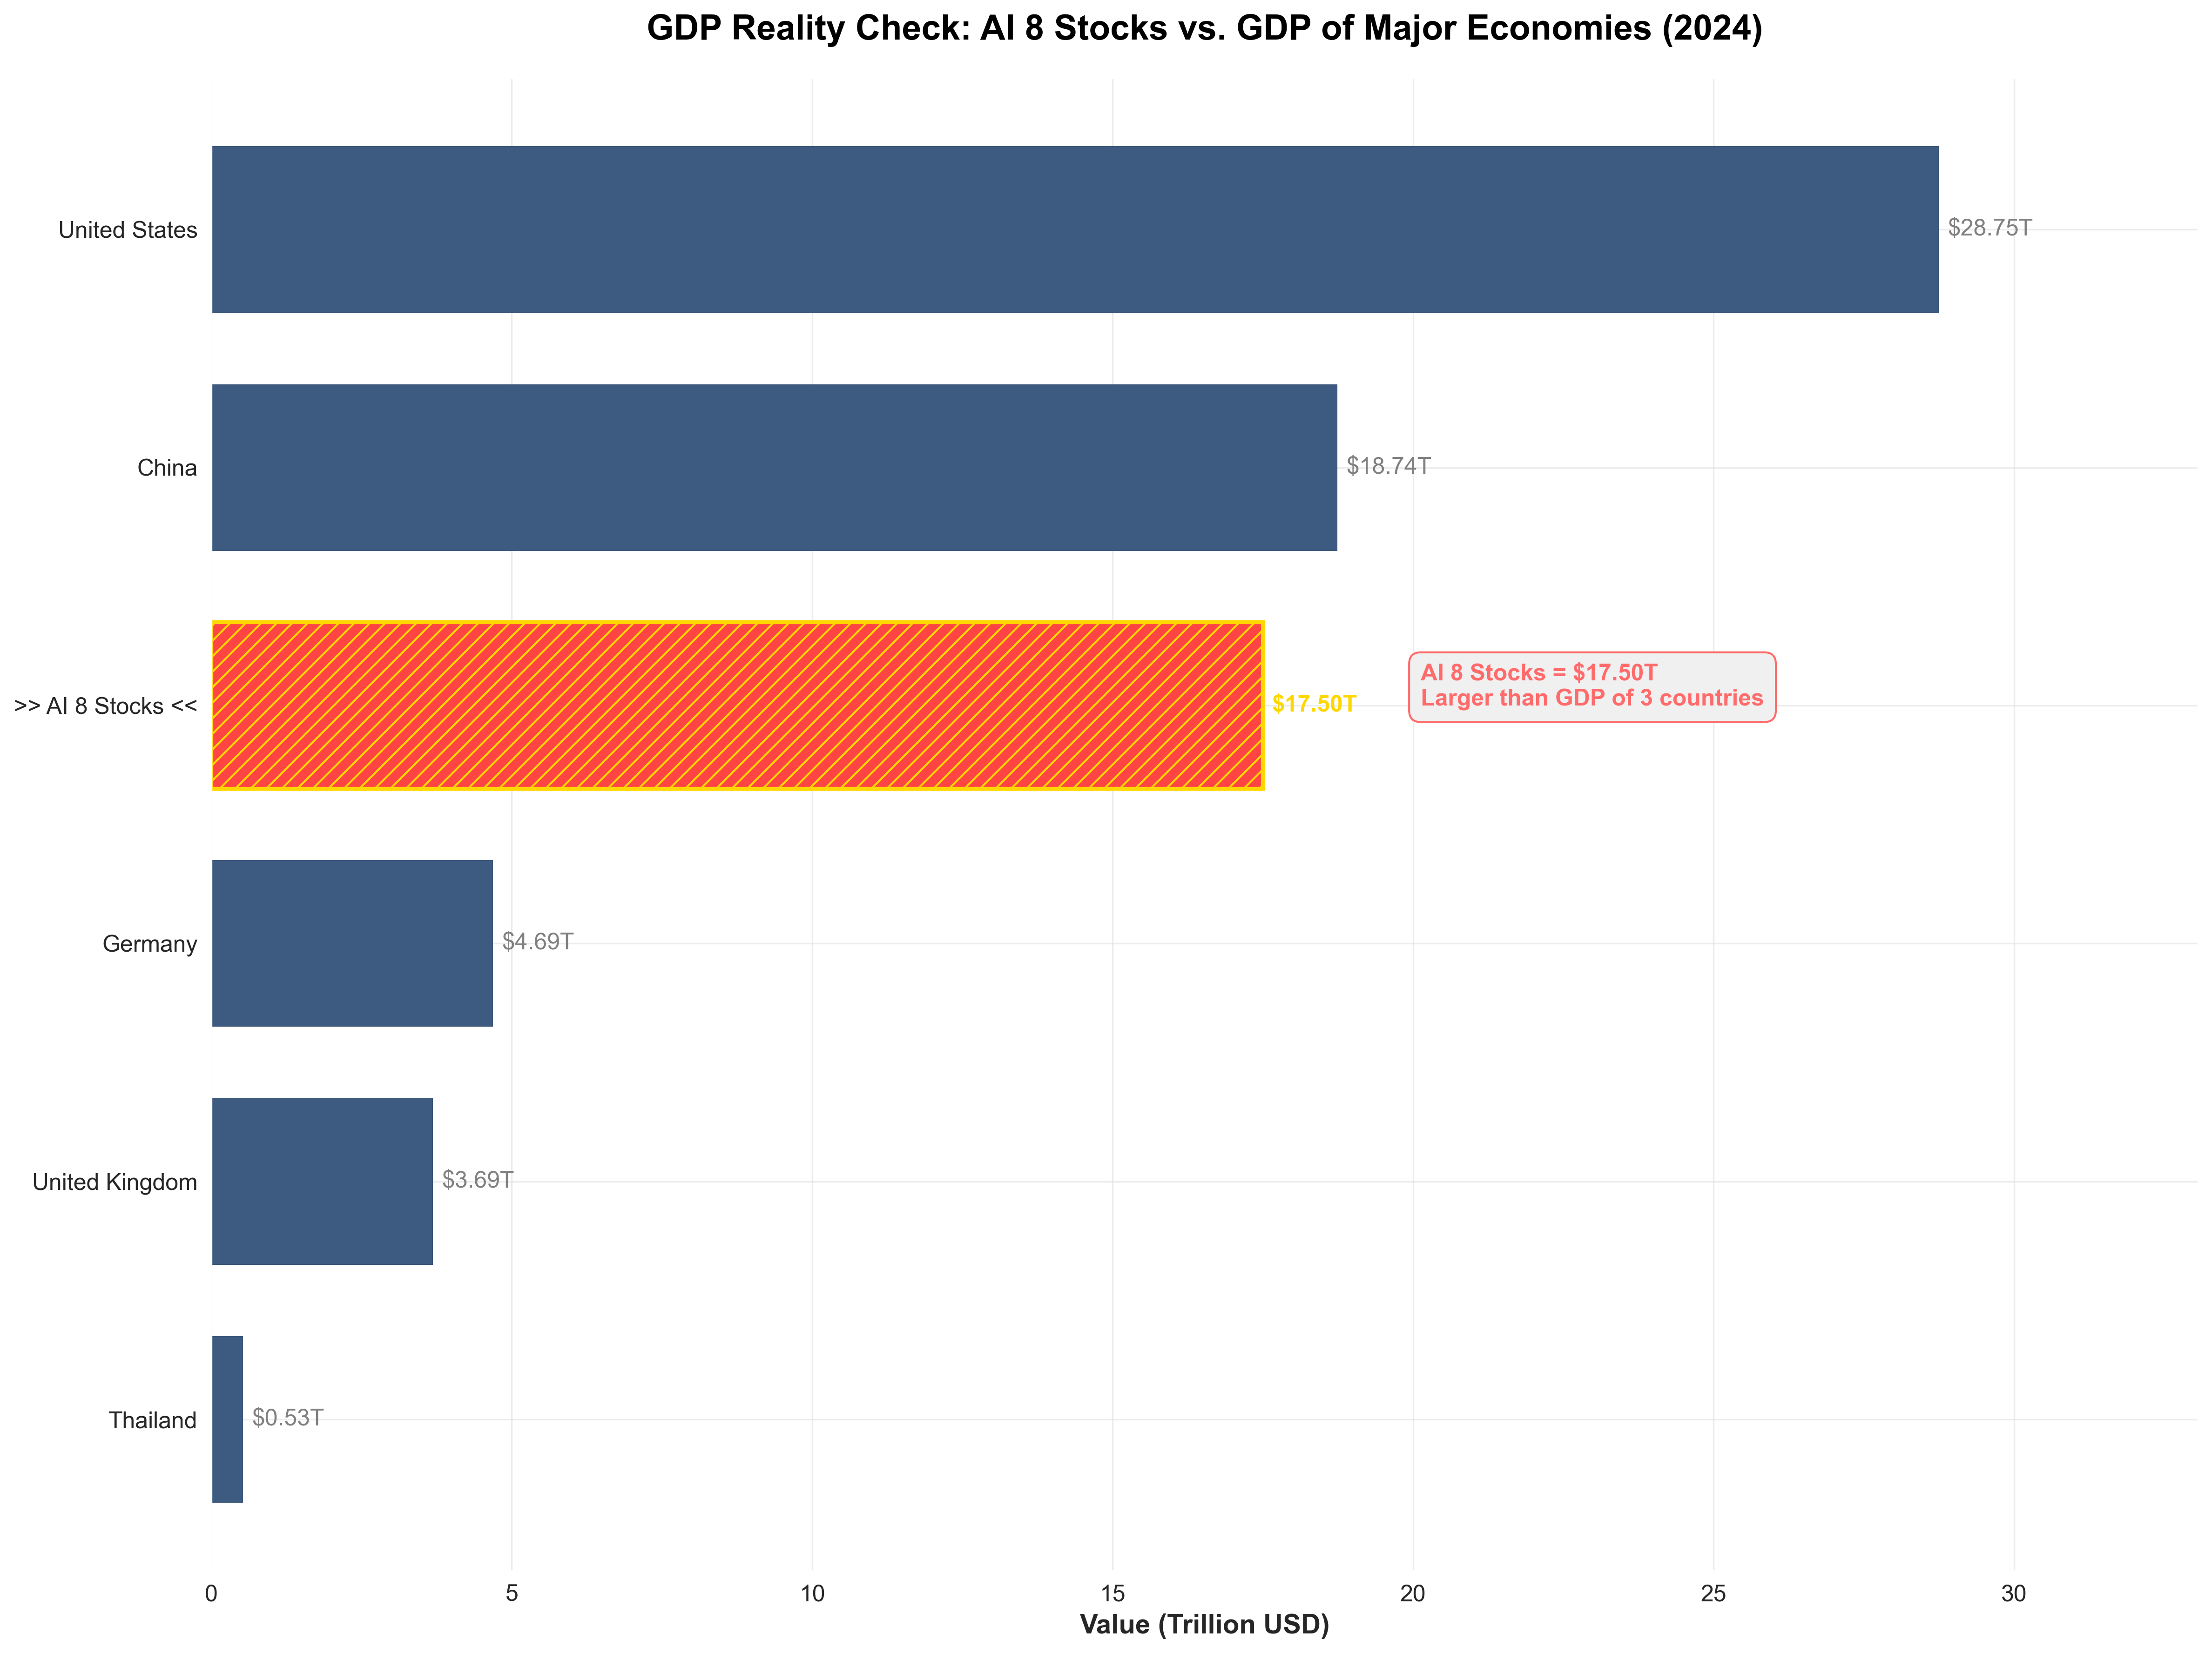

In [12]:
# Visualization: GDP vs AI Market Cap 
fig, ax = plt.subplots(figsize=(16, 12))

bar_colors = []
for entity in comp_df['Entity']:
    if 'AI' in entity:
        bar_colors.append('#FF4444')
    else:
        bar_colors.append('#3d5a80')

bars = ax.barh(comp_df['Entity'], comp_df['Value_T'], color=bar_colors,
               edgecolor='#00000011', linewidth=0.5, height=0.7)

# Highlight the AI bar
for bar, entity in zip(bars, comp_df['Entity']):
    if 'AI' in entity:
        bar.set_edgecolor('#FFD700')
        bar.set_linewidth(2)
        bar.set_hatch('///')

# Value labels
for bar, row in zip(bars, comp_df.itertuples()):
    width = bar.get_width()
    color = '#FFD700' if 'AI' in row.Entity else '#808080'
    weight = 'bold' if 'AI' in row.Entity else 'normal'
    ax.text(width + 0.15, bar.get_y() + bar.get_height()/2,
            f'${width:.2f}T', va='center', fontsize=12, color=color, fontweight=weight)

ax.set_xlabel('Value (Trillion USD)', fontweight='bold', fontsize=14)
ax.set_title('GDP Reality Check: AI 8 Stocks vs. GDP of Major Economies (2024)',
             fontsize=18, fontweight='bold', pad=20, color='black')

ai_val = total_ai_mcap / 1e12
exceeded = [k for k, v in gdp_data.items() if v < ai_val]
ax.set_xlim(0, comp_df['Value_T'].max() * 1.15)

# Add annotation
ax.annotate(f'AI 8 Stocks = ${ai_val:.2f}T\nLarger than GDP of {len(exceeded)} countries',
            xy=(ai_val, comp_df[comp_df['Entity'].str.contains('AI')].index[0]),
            xytext=(ai_val * 1.15, len(comp_df) - 3),
            fontsize=12, color='#FF6B6B', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', edgecolor='#FF6B6B'))

plt.tight_layout()
plt.savefig('figure2.png', bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

### Section 2 Insight

In [14]:
# --- Section 2 Insight ---
ai_val_t = total_ai_mcap / 1e12
exceeded_countries = [(k, v) for k, v in gdp_data.items() if v < ai_val_t]
exceeded_countries.sort(key=lambda x: x[1], reverse=True)

print("=" * 70)
print("INSIGHT: GDP Reality Check")
print("=" * 70)
print(f"  Total AI 8 Stocks Market Cap: ${ai_val_t:.2f} Trillion")
print(f"  Larger than the GDP of {len(exceeded_countries)} out of {len(gdp_data)} countries:")
print()
for country, gdp in exceeded_countries:
    ratio = ai_val_t / gdp
    print(f"     - {country}: ${gdp:.2f}T (AI is {ratio:.1f}x larger)")

germany_gdp = gdp_data.get('Germany', 4.69)
print(f"\n  Compared to Germany (GDP ${germany_gdp:.2f}T):")
if ai_val_t > germany_gdp:
    print(f"     > AI 8 Stocks are {ai_val_t/germany_gdp:.1f}x the entire German economy!")
else:
    print(f"     > AI 8 Stocks are still smaller ({ai_val_t/germany_gdp:.1f}x)")

china_gdp = gdp_data.get('China', 18.74)
print(f"\n  Compared to China (GDP ${china_gdp:.2f}T):")
if ai_val_t > china_gdp:
    print(f"     > AI 8 Stocks exceed the entire Chinese economy!")
else:
    print(f"     > AI 8 Stocks = {ai_val_t/china_gdp:.1f}x of Chinese economy")

print(f"\n  Key takeaway: Just 8 companies have a combined valuation that")
print(f"  rivals entire national economies with hundreds of millions of people.")
print("=" * 70)

INSIGHT: GDP Reality Check
  Total AI 8 Stocks Market Cap: $17.50 Trillion
  Larger than the GDP of 3 out of 5 countries:

     - Germany: $4.69T (AI is 3.7x larger)
     - United Kingdom: $3.69T (AI is 4.7x larger)
     - Thailand: $0.53T (AI is 33.0x larger)

  Compared to Germany (GDP $4.69T):
     > AI 8 Stocks are 3.7x the entire German economy!

  Compared to China (GDP $18.74T):
     > AI 8 Stocks = 0.9x of Chinese economy

  Key takeaway: Just 8 companies have a combined valuation that
  rivals entire national economies with hundreds of millions of people.


---
# 3. Market Breadth Analysis - Who Is Carrying the Market?
---

### Objective
Is the current market rally broad-based, or is it driven entirely by AI stocks?

### Methodology
- Compare S&P 500 (Market Cap Weighted), which is heavily tilted toward AI,
  against S&P 500 Equal Weight, which gives every stock the same influence
- Calculate the average return of the 8 AI stocks

If AI returns are very high but the Equal Weight S&P 500 is barely up, it means
"the economy is not actually strong - AI is propping up the index" (Narrow Market Rally).

In [15]:
# Calculate Cumulative Returns 
# Compute returns from all_stocks
ai_returns_all = pd.DataFrame()
for ticker in AI_TICKERS:
    sub = all_stocks[all_stocks['Ticker'] == ticker].set_index('Date')['Close']
    ret = (sub / sub.iloc[0] - 1) * 100
    ai_returns_all[ticker] = ret

# S&P 500 returns
gspc_close = gspc['Close'].copy()
gspc_return = (gspc_close / gspc_close.iloc[0] - 1) * 100

sp500ew_close = sp500ew['Close'].copy()
sp500ew_return = (sp500ew_close / sp500ew_close.iloc[0] - 1) * 100

# Align dates
common_dates = ai_returns_all.index.intersection(gspc_return.index).intersection(sp500ew_return.index)
ai_returns_aligned = ai_returns_all.loc[common_dates]
gspc_return_aligned = gspc_return.loc[common_dates]
sp500ew_return_aligned = sp500ew_return.loc[common_dates]
ai_avg_return = ai_returns_aligned.mean(axis=1)

print("=" * 70)
print("CUMULATIVE RETURNS SUMMARY (Jan 2023 to Latest)")
print("=" * 70)
print(f"  {'Index/Group':<35s} {'Return':>10s}")
print("-" * 50)
print(f"  {'AI 8 Stocks (Average)':<35s} {ai_avg_return.iloc[-1]:>+9.1f}%")
for ticker in AI_TICKERS:
    if ticker in ai_returns_aligned.columns:
        print(f"    - {ticker:<31s} {ai_returns_aligned[ticker].iloc[-1]:>+9.1f}%")
print(f"  {'S&P 500 (Market Cap Weight)':<35s} {gspc_return_aligned.iloc[-1]:>+9.1f}%")
print(f"  {'S&P 500 (Equal Weight)':<35s} {sp500ew_return_aligned.iloc[-1]:>+9.1f}%")
print("-" * 50)
gap = ai_avg_return.iloc[-1] - sp500ew_return_aligned.iloc[-1]
print(f"  {'Gap (AI Avg - EW)':<35s} {gap:>+9.1f}%")
print("=" * 70)

CUMULATIVE RETURNS SUMMARY (Jan 2023 to Latest)
  Index/Group                             Return
--------------------------------------------------
  AI 8 Stocks (Average)                  +661.8%
    - NVDA                              +1211.4%
    - AMD                                +236.4%
    - AMZN                               +171.0%
    - GOOGL                              +254.8%
    - META                               +437.6%
    - MSFT                               +108.3%
    - ORCL                               +144.5%
    - PLTR                              +2730.0%
  S&P 500 (Market Cap Weight)             +80.3%
  S&P 500 (Equal Weight)                  +36.6%
--------------------------------------------------
  Gap (AI Avg - EW)                      +625.1%


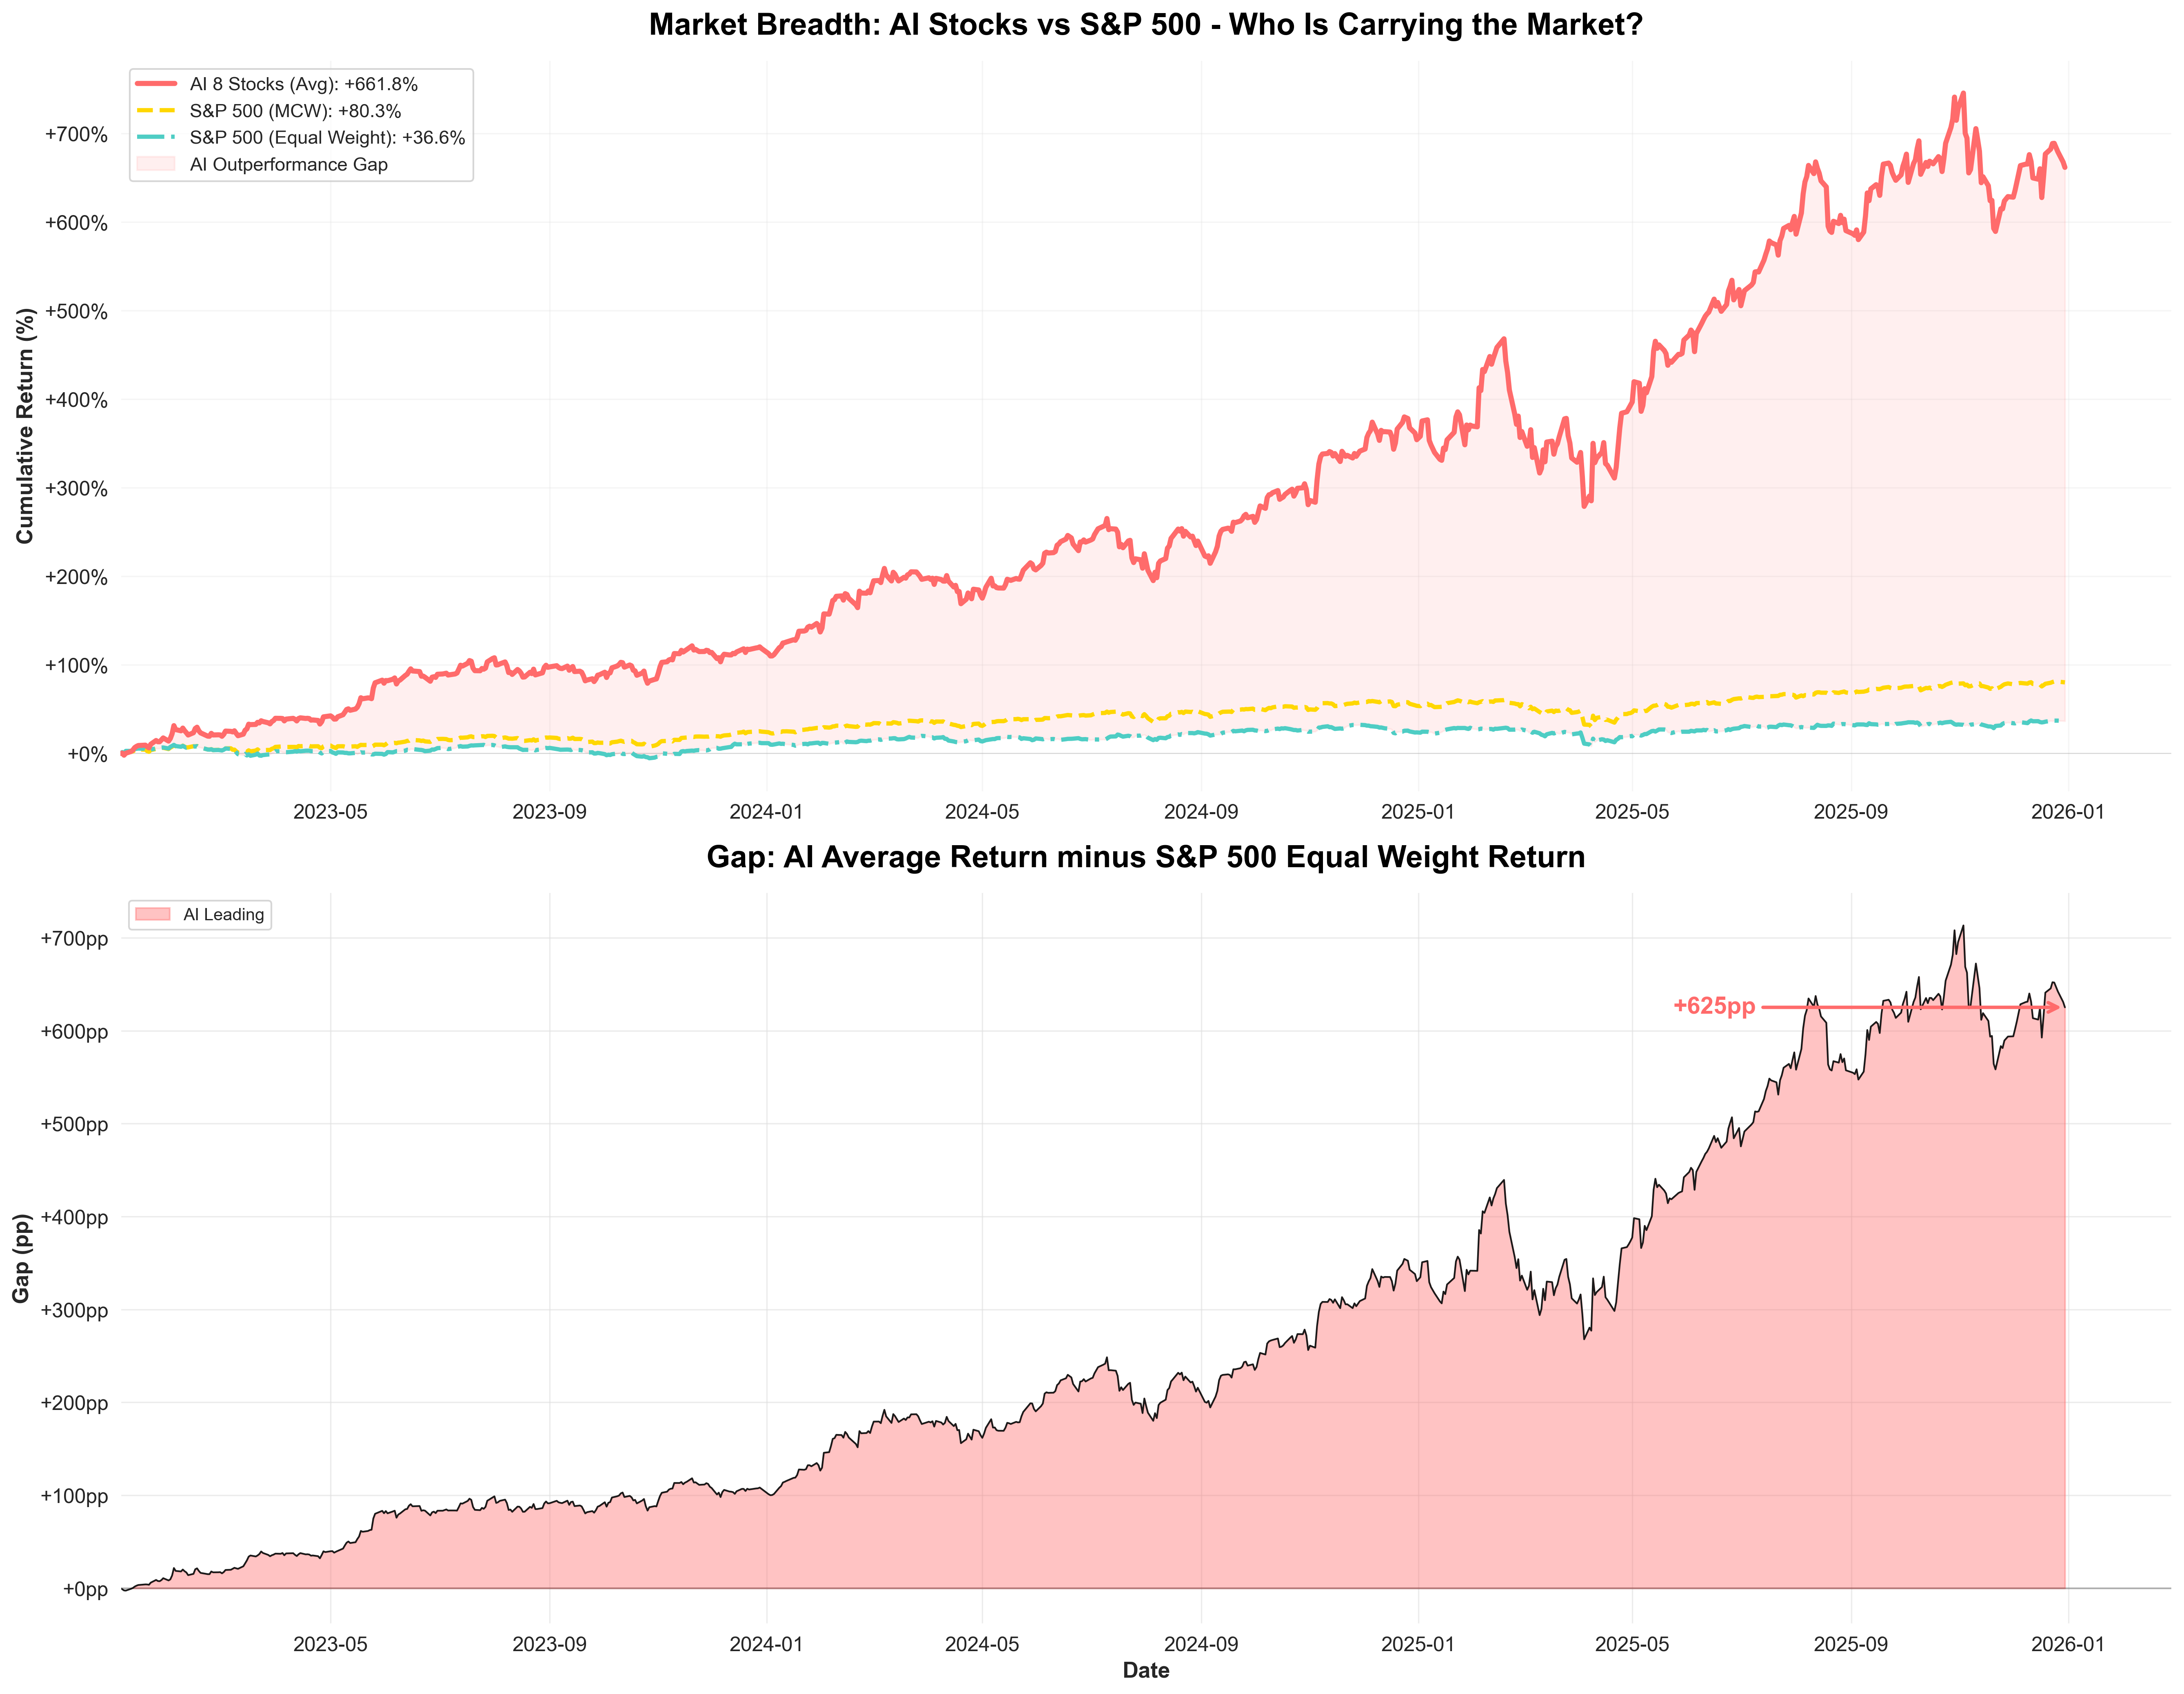

In [17]:
# Visualization: Market Breadth 
fig, axes = plt.subplots(2, 1, figsize=(18, 14), height_ratios=[1, 1])

# TOP: Cumulative Return Lines
ax1 = axes[0]

# Plot main lines (NO individual AI stock lines)
ax1.plot(ai_avg_return.index, ai_avg_return,
         color='#FF6B6B', linewidth=3, label=f'AI 8 Stocks (Avg): {ai_avg_return.iloc[-1]:+.1f}%',
         zorder=5)
ax1.plot(gspc_return_aligned.index, gspc_return_aligned,
         color='#FFD700', linewidth=2.5, label=f'S&P 500 (MCW): {gspc_return_aligned.iloc[-1]:+.1f}%',
         linestyle='--', zorder=4)
ax1.plot(sp500ew_return_aligned.index, sp500ew_return_aligned,
         color='#4ECDC4', linewidth=2.5, label=f'S&P 500 (Equal Weight): {sp500ew_return_aligned.iloc[-1]:+.1f}%',
         linestyle='-.', zorder=4)

ax1.axhline(y=0, color='#00000022', linewidth=0.5, linestyle='-')
ax1.fill_between(ai_avg_return.index, ai_avg_return, sp500ew_return_aligned,
                  where=ai_avg_return > sp500ew_return_aligned,
                  alpha=0.1, color='#FF6B6B', label='AI Outperformance Gap')

ax1.set_title('Market Breadth: AI Stocks vs S&P 500 - Who Is Carrying the Market?',
              fontsize=18, fontweight='bold', pad=15, color='black')
ax1.set_ylabel('Cumulative Return (%)', fontweight='bold')
ax1.legend(loc='upper left', fontsize=11, framealpha=0.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax1.grid(True, alpha=0.3)

# BOTTOM: Gap (AI - Equal Weight) over time
ax2 = axes[1]
gap_series = ai_avg_return - sp500ew_return_aligned
ax2.fill_between(gap_series.index, gap_series, 0,
                  where=gap_series > 0, color='#FF6B6B', alpha=0.4, label='AI Leading')
ax2.plot(gap_series.index, gap_series, color='#1a1a1a', linewidth=1)
ax2.axhline(y=0, color='#00000044', linewidth=1, linestyle='-')

# Add arrow pointing to the last data point on the Gap chart
last_date = gap_series.index[-1]
arrow_offset_x = pd.Timedelta(days=-220)

ax2.annotate(f'{gap_series.iloc[-1]:+.0f}pp',
             xy=(last_date, gap_series.iloc[-1]),
             xytext=(last_date + arrow_offset_x, gap_series.iloc[-1]),
             fontsize=14, fontweight='bold', color='#FF6B6B',
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=2),
             va='center', ha='left', zorder=10)

ax2.set_title('Gap: AI Average Return minus S&P 500 Equal Weight Return',
              fontsize=18, fontweight='bold', pad=15, color='black')
ax2.set_ylabel('Gap (pp)', fontweight='bold')
ax2.set_xlabel('Date', fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}pp'))

# Extend x-axis on both charts for arrow room
x_margin = pd.Timedelta(days=60)
ax1.set_xlim(ai_avg_return.index[0], last_date + x_margin)
ax2.set_xlim(gap_series.index[0], last_date + x_margin)

plt.tight_layout()
plt.savefig('figure3.png', bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

### Section 3 Insight

In [ ]:
# Section 3 Insight 
ai_ret = ai_avg_return.iloc[-1]
gspc_ret = gspc_return_aligned.iloc[-1]
ew_ret = sp500ew_return_aligned.iloc[-1]
breadth_gap = ai_ret - ew_ret

print("=" * 70)
print("INSIGHT: Market Breadth Analysis")
print("=" * 70)
print(f"  AI 8 Stocks (Average Return):     {ai_ret:+.1f}%")
print(f"  S&P 500 (Market Cap Weight):       {gspc_ret:+.1f}%")
print(f"  S&P 500 (Equal Weight):            {ew_ret:+.1f}%")
print(f"  Gap (AI - Equal Weight):           {breadth_gap:+.1f} pp")
print()

if breadth_gap > 50:
    print("  [ALERT] NARROW MARKET RALLY")
    print(f"     > AI stocks are up {ai_ret:+.1f}% while the broader market (EW) is up only {ew_ret:+.1f}%")
    print(f"     > The {breadth_gap:.0f}pp gap indicates the economy is not truly strong -")
    print(f"       AI names are propping up the S&P 500 index")
    print(f"     > S&P 500 gained {gspc_ret:+.1f}% largely because AI stocks pulled it higher")
    print(f"     > If AI collapses, the market will reveal its true underlying weakness")
elif breadth_gap > 20:
    print("  [WARNING] MODERATE GAP")
    print(f"     > AI is outperforming the broader market, but not yet at crisis levels")
else:
    print("  [OK] BROAD RALLY")
    print(f"     > The market rally is relatively broad-based, not solely dependent on AI")
print("=" * 70)

INSIGHT: Market Breadth Analysis
  AI 8 Stocks (Average Return):     +661.8%
  S&P 500 (Market Cap Weight):       +80.3%
  S&P 500 (Equal Weight):            +36.6%
  Gap (AI - Equal Weight):           +625.1 pp

  [ALERT] NARROW MARKET RALLY
     > AI stocks are up +661.8% while the broader market (EW) is up only +36.6%
     > The 625pp gap indicates the economy is not truly strong -
       AI names are propping up the S&P 500 index
     > S&P 500 gained +80.3% largely because AI stocks pulled it higher
     > If AI collapses, the market will reveal its true underlying weakness


---
# 4. The "Crash" Simulation - Stress Test
---

### Objective
If the AI bubble bursts (assume 20-50% decline), how badly would the S&P 500 suffer?

### Methodology
- Use the Weight data from Section 1
- Run Scenario Analysis:
  - **Scenario A:** AI 8 stocks fall -10% (Minor Correction)
  - **Scenario B:** AI 8 stocks fall -20% (Correction)
  - **Scenario C:** AI 8 stocks fall -30% (Bear Market)
  - **Scenario D:** AI 8 stocks fall -40% (Severe Bear)
  - **Scenario E:** AI 8 stocks fall -50% (Bubble Burst)
- **Formula:** S&P 500 Impact = AI Weight x AI Drop

This answers the question: "Can the market survive if NVIDIA and friends collapse?"

In [ ]:
# Scenario Analysis
scenarios = {
    'Minor Correction': -10,
    'Correction': -20,
    'Bear Market': -30,
    'Severe Bear': -40,
    'Bubble Burst': -50,
}

impact_data = []
for scenario_name, ai_drop in scenarios.items():
    scenario_row = {'Scenario': scenario_name, 'AI Drop (%)': ai_drop}
    total_impact = 0
    for ticker in AI_TICKERS:
        weight = mcap_df[mcap_df['Ticker'] == ticker]['Weight_Pct'].values[0]
        impact = weight * (ai_drop / 100)
        scenario_row[ticker] = round(impact, 2)
        total_impact += impact
    scenario_row['Total S&P 500 Impact (%)'] = round(total_impact, 2)
    latest_sp500 = gspc['Close'].iloc[-1]
    scenario_row['S&P 500 Points Lost'] = round(latest_sp500 * total_impact / 100, 0)
    scenario_row['S&P 500 New Level'] = round(latest_sp500 + (latest_sp500 * total_impact / 100), 0)
    impact_data.append(scenario_row)

impact_df = pd.DataFrame(impact_data)

print("=" * 90)
print("CRASH SIMULATION - S&P 500 Impact if AI Stocks Decline")
print("=" * 90)
print(f"  Current S&P 500 Level: {latest_sp500:,.2f}")
print(f"  Total AI Weight: {total_ai_weight:.1f}%")
print("-" * 90)
print(f"  {'Scenario':<20s} {'AI Drop':>10s} {'S&P Impact':>13s} {'Points Lost':>14s} {'New Level':>12s}")
print("-" * 90)
for _, row in impact_df.iterrows():
    print(f"  {row['Scenario']:<20s} {row['AI Drop (%)']:>+9.0f}%  {row['Total S&P 500 Impact (%)']:>+12.2f}%  "
          f"{row['S&P 500 Points Lost']:>+13,.0f}  {row['S&P 500 New Level']:>11,.0f}")
print("=" * 90)

CRASH SIMULATION - S&P 500 Impact if AI Stocks Decline
  Current S&P 500 Level: 6,896.24
  Total AI Weight: 35.0%
------------------------------------------------------------------------------------------
  Scenario                AI Drop    S&P Impact    Points Lost    New Level
------------------------------------------------------------------------------------------
  Minor Correction           -10%         -3.50%           -241        6,655
  Correction                 -20%         -7.00%           -483        6,413
  Bear Market                -30%        -10.50%           -724        6,172
  Severe Bear                -40%        -14.00%           -966        5,931
  Bubble Burst               -50%        -17.50%         -1,207        5,689


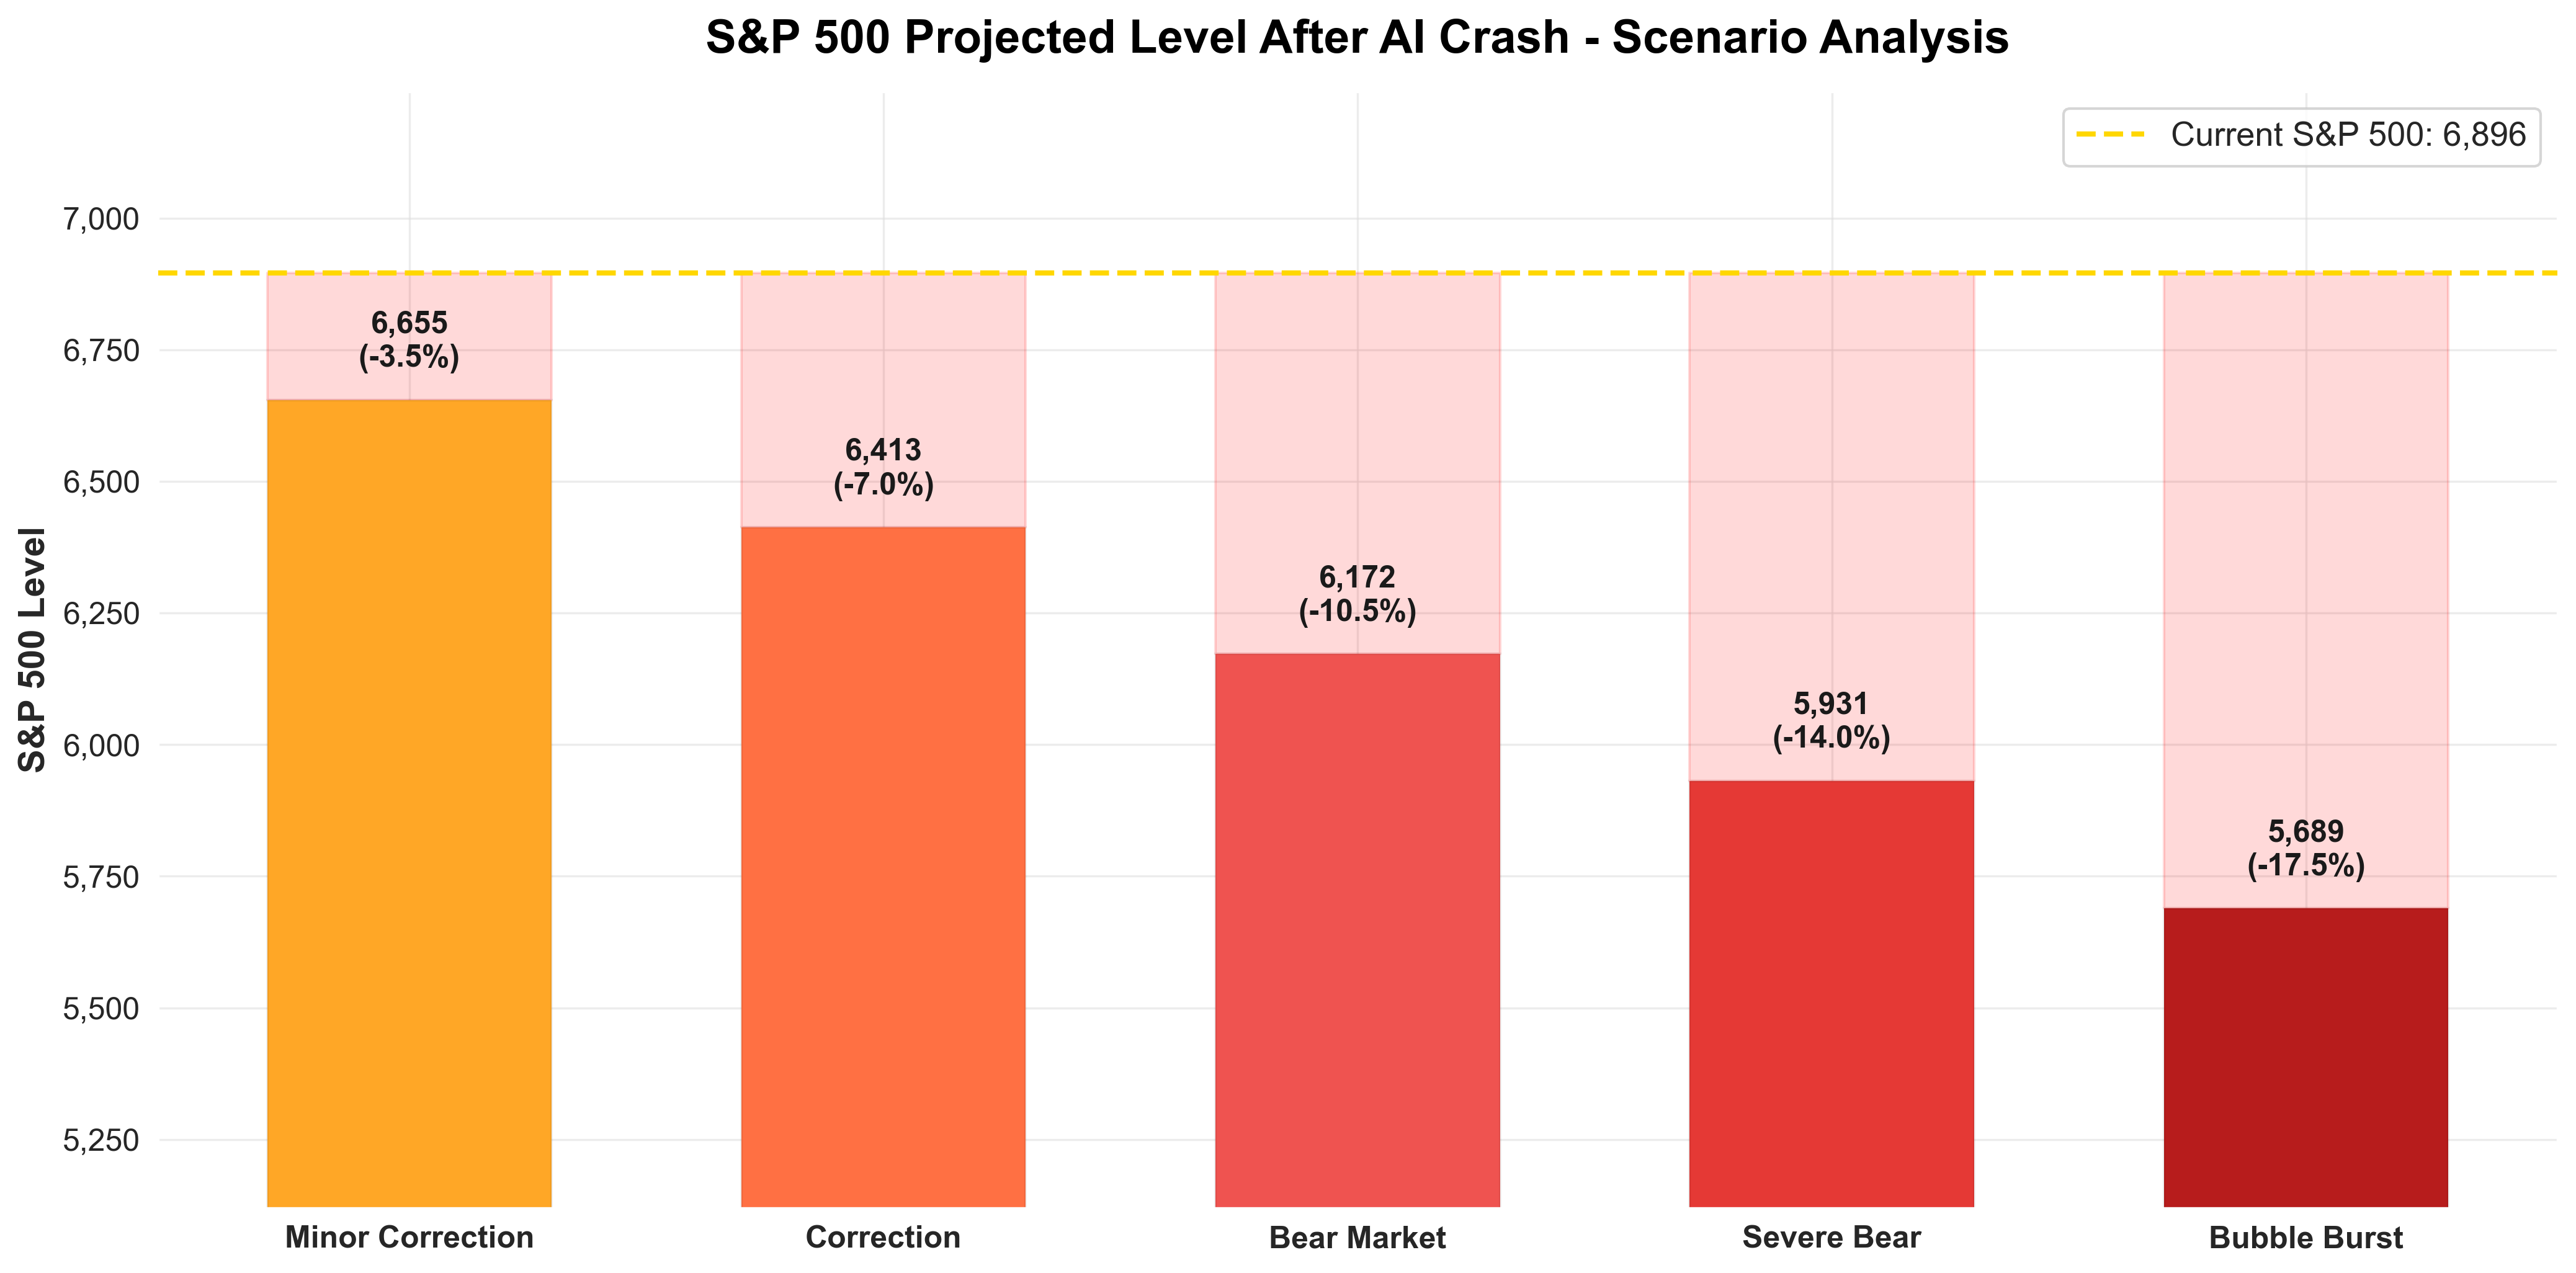

In [ ]:
# Additional Visualization: S&P 500 Levels After Crash 
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(impact_df))
current_level = latest_sp500

ax.axhline(y=current_level, color='#FFD700', linewidth=2, linestyle='--',
           label=f'Current S&P 500: {current_level:,.0f}', zorder=3)

new_levels = impact_df['S&P 500 New Level'].values
drops = impact_df['Total S&P 500 Impact (%)'].values
colors_bar = ['#FFA726', '#FF7043', '#EF5350', '#E53935', '#B71C1C']

bars = ax.bar(x, new_levels, color=colors_bar, edgecolor='#00000011',
              width=0.6, zorder=2)

for i, (bar, new_lv, drop) in enumerate(zip(bars, new_levels, drops)):
    ax.text(bar.get_x() + bar.get_width()/2, new_lv + 50,
            f'{new_lv:,.0f}\n({drop:+.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='#1a1a1a')
    bar_left = bar.get_x()
    bar_right = bar.get_x() + bar.get_width()
    ax.fill_between([bar_left, bar_right],
                     [new_lv, new_lv], [current_level, current_level],
                     alpha=0.15, color='red')

ax.set_xticks(x)
ax.set_xticklabels(impact_df['Scenario'], fontsize=12, fontweight='bold')
ax.set_ylabel('S&P 500 Level', fontweight='bold', fontsize=14)
ax.set_title('S&P 500 Projected Level After AI Crash - Scenario Analysis',
             fontsize=18, fontweight='bold', pad=15, color='black')
ax.legend(fontsize=13, loc='upper right')
ax.set_ylim(min(new_levels) * 0.9, current_level * 1.05)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('figure4.png', bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

### Section 4 Insight

In [22]:
# Section 4 Final Insight
worst_case = impact_df[impact_df['Scenario'] == 'Bubble Burst'].iloc[0]
correction_case = impact_df[impact_df['Scenario'] == 'Correction'].iloc[0]

print("=" * 70)
print("INSIGHT: Crash Simulation - Stress Test Results")
print("=" * 70)
print(f"  Current S&P 500: {latest_sp500:,.2f}")
print(f"  Total AI Weight: {total_ai_weight:.1f}%")
print()
print(f"  Scenario: Correction (AI drops -20%)")
print(f"     > S&P 500 Impact:    {correction_case['Total S&P 500 Impact (%)']:+.2f}%")
print(f"     > Points Lost:       {correction_case['S&P 500 Points Lost']:+,.0f}")
print(f"     > New S&P 500 Level: {correction_case['S&P 500 New Level']:,.0f}")
print()
print(f"  Scenario: Bubble Burst (AI drops -50%)")
print(f"     > S&P 500 Impact:    {worst_case['Total S&P 500 Impact (%)']:+.2f}%")
print(f"     > Points Lost:       {worst_case['S&P 500 Points Lost']:+,.0f}")
print(f"     > New S&P 500 Level: {worst_case['S&P 500 New Level']:,.0f}")
print()
print("  Key conclusions:")
print(f"     > A mere -20% AI correction would drag S&P 500 down {abs(correction_case['Total S&P 500 Impact (%)']):.1f}%")
print(f"     > A -50% AI crash would instantly wipe {abs(worst_case['Total S&P 500 Impact (%)']):.1f}% off the S&P 500")
print(f"     > These figures do NOT include the contagion effect - panic selling")
print(f"       would likely cause other non-AI stocks to decline as well,")
print(f"       amplifying the total market drawdown beyond these estimates")
print("=" * 70)

INSIGHT: Crash Simulation - Stress Test Results
  Current S&P 500: 6,896.24
  Total AI Weight: 35.0%

  Scenario: Correction (AI drops -20%)
     > S&P 500 Impact:    -7.00%
     > Points Lost:       -483
     > New S&P 500 Level: 6,413

  Scenario: Bubble Burst (AI drops -50%)
     > S&P 500 Impact:    -17.50%
     > Points Lost:       -1,207
     > New S&P 500 Level: 5,689

  Key conclusions:
     > A mere -20% AI correction would drag S&P 500 down 7.0%
     > A -50% AI crash would instantly wipe 17.5% off the S&P 500
     > These figures do NOT include the contagion effect - panic selling
       would likely cause other non-AI stocks to decline as well,
       amplifying the total market drawdown beyond these estimates


---
# Summary
---

In [24]:
# --- Final Executive Summary ---
ai_val_t = total_ai_mcap / 1e12
exceeded_countries = [(k, v) for k, v in gdp_data.items() if v < ai_val_t]
exceeded_countries.sort(key=lambda x: x[1], reverse=True)
germany_gdp = gdp_data.get('Germany', 4.69)
ai_ret = ai_avg_return.iloc[-1]
ew_ret = sp500ew_return_aligned.iloc[-1]
breadth_gap = ai_ret - ew_ret

print("=" * 70)
print(" EXECUTIVE SUMMARY: AI Market Weight & Impact Analysis".center(70))
print("=" * 70)
print()
print("  1. WEIGHT ANALYSIS")
print(f"     - AI 8 Stocks = {total_ai_weight:.1f}% of S&P 500")
nvda_wt = mcap_df[mcap_df['Ticker']=='NVDA']['Weight_Pct'].values[0]
print(f"     - NVDA alone = {nvda_wt:.1f}%")
if total_ai_weight > 30:
    print("     - [WARNING] Concentration Risk is critical (>30%)")
print()
print("  2. GDP REALITY CHECK")
print(f"     - AI 8 Stocks = ${ai_val_t:.1f}T")
print(f"     - Larger than GDP of {len(exceeded_countries)} out of {len(gdp_data)} countries")
if ai_val_t > germany_gdp:
    print(f"     - {ai_val_t/germany_gdp:.1f}x larger than Germany")
print()
print("  3. MARKET BREADTH")
print(f"     - AI Avg Return:     {ai_ret:+.1f}%")
print(f"     - S&P 500 EW Return: {ew_ret:+.1f}%")
print(f"     - Gap:               {breadth_gap:+.1f}pp")
if breadth_gap > 50:
    print("     - [ALERT] Narrow Market Rally")
print()
print("  4. CRASH SIMULATION")
print(f"     - AI -20% => S&P 500 {correction_case['Total S&P 500 Impact (%)']:+.1f}%")
print(f"     - AI -50% => S&P 500 {worst_case['Total S&P 500 Impact (%)']:+.1f}%")
print()
print("  BOTTOM LINE:")
print("     The S&P 500 is excessively dependent on AI stocks.")
print("     If AI stocks collapse, the entire market suffers severe damage.")
print()
print("=" * 70)

         EXECUTIVE SUMMARY: AI Market Weight & Impact Analysis        

  1. WEIGHT ANALYSIS
     - AI 8 Stocks = 35.0% of S&P 500
     - NVDA alone = 9.1%
     - [WARNING] Concentration Risk is critical (>30%)

  2. GDP REALITY CHECK
     - AI 8 Stocks = $17.5T
     - Larger than GDP of 3 out of 5 countries
     - 3.7x larger than Germany

  3. MARKET BREADTH
     - AI Avg Return:     +661.8%
     - S&P 500 EW Return: +36.6%
     - Gap:               +625.1pp
     - [ALERT] Narrow Market Rally

  4. CRASH SIMULATION
     - AI -20% => S&P 500 -7.0%
     - AI -50% => S&P 500 -17.5%

  BOTTOM LINE:
     The S&P 500 is excessively dependent on AI stocks.
     If AI stocks collapse, the entire market suffers severe damage.

